# Smart Irrigation System – Data & AI Notebook

## 1 Import libraries

In [12]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

## 2 Load JSON dataset

In [2]:
with open('data.json') as f:
    data=json.load(f)
df=pd.DataFrame(data)
df.head()

,timestamp,sensor_id,sensor_name,zone,soil_humidity_%,temperature_C,alert_type,alert_severity,irrigation,irrigation_duration_min
0,2026-03-01 00:00:00,1,Zone A â€” Nord,Nord,64.77,17.19,None,None,False,0
1,2026-03-01 00:00:00,2,Zone B â€” Centre,Centre,58.08,19.57,None,None,False,0
2,2026-03-01 00:00:00,3,Zone C â€” Sud,Sud,50.94,21.51,None,None,False,0
3,2026-03-01 00:00:00,4,Zone D â€” Est,Est,60.64,17.52,None,None,False,0
4,2026-03-01 01:00:00,1,Zone A â€” Nord,Nord,76.14,18.12,None,None,False,0


## 3 Explore data

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                672 non-null    object 
 1   sensor_id                672 non-null    int64  
 2   sensor_name              672 non-null    object 
 3   zone                     672 non-null    object 
 4   soil_humidity_%          672 non-null    float64
 5   temperature_C            672 non-null    float64
 6   alert_type               235 non-null    object 
 7   alert_severity           235 non-null    object 
 8   irrigation               672 non-null    bool   
 9   irrigation_duration_min  672 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 48.0+ KB


,sensor_id,soil_humidity_%,temperature_C,irrigation_duration_min
count,672.000000,672.000000,672.000000,672.000000
mean,2.500000,56.533839,28.904717,4.159226
std,1.118867,28.091357,6.741015,9.577511
min,1.000000,10.000000,16.150000,0.000000
25%,1.750000,30.607500,22.827500,0.000000
50%,2.500000,54.370000,28.750000,0.000000
75%,3.250000,85.042500,34.877500,0.000000
max,4.000000,95.000000,42.250000,40.000000


## 4 Clean data

In [4]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.dropna()

## 5 Visualization

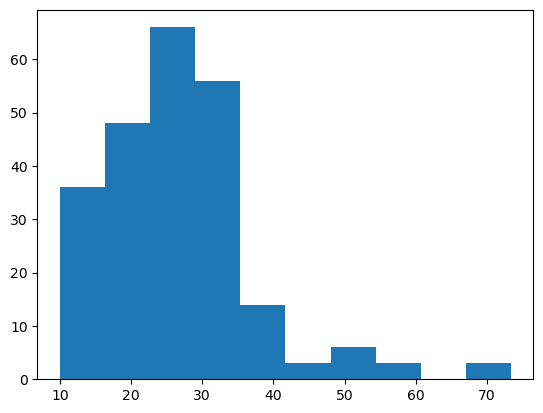

In [5]:
plt.hist(df['soil_humidity_%'])
plt.show()

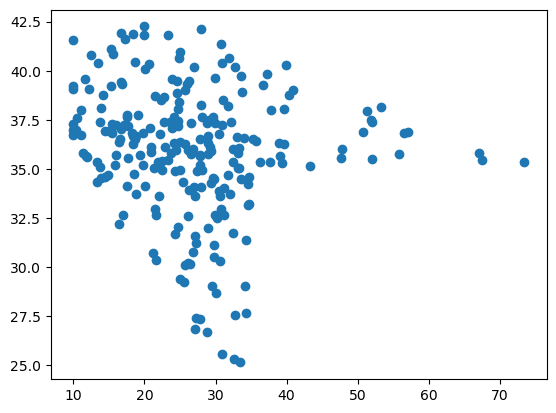

In [6]:
plt.scatter(df['soil_humidity_%'],df['temperature_C'])
plt.show()

## 6 Prepare ML data

In [7]:
X=df[['soil_humidity_%','temperature_C']]
y=df['irrigation'].astype(int)

## 7 Train test split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 8 Train model

In [9]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

## 9 Evaluate model

In [10]:
pred=model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,pred))

Accuracy: 1.0


## 10 Save model

In [ ]:
joblib.dump(model,'irrigation_model.pkl')

: 